# Voxter: Implementation‑Synchronized Theory

This notebook presents a formal and rigorous exposition of the Voxter project, a real‑time visuomotor agent designed for Geometry Dash. It follows the structure of the implementation‑synchronized theory document and provides clear definitions, mathematical formulations, and architectural details. The goal is to make the theory auditable from the available artifacts and to articulate the contracts that guide development and evaluation.


## 1. Introduction and policy thesis

Voxter is **not** a timestamp replay bot. It is a causal agent whose decision at each tick is conditioned on the current and recent visual observations as well as the previous action. Formally, the control problem is:

* Given the current grayscale observation, a short history of observations (a frame stack), and the previous applied action, should the input be **held** or **released** during the next control interval?

Let $A = \{0,1\}$ denote the binary action space, where $a_t=1$ means the jump button is held and $a_t=0$ means it is released. The policy is parameterized by $\theta$ and is a mapping $\pi_{\theta}(a_t \mid H_t)$ from the history $H_t$ to a Bernoulli distribution over $A$. The history includes the most recent $k$ grayscale frames and the previous action. The agent also predicts transition events to aid decoding:

$$
\pi_{\theta}(a_t = 1 \mid H_t) = \sigma(\ell_{\text{held},t}),\quad e^{\text{press}}_t = \mathbb{1}[a_{t-1}=0 \wedge a_t=1],\quad e^{\text{release}}_t = \mathbb{1}[a_{t-1}=1 \wedge a_t=0].
$$

The canonical action representation remains the **held state**. Press and release events are derived transitions used as auxiliary predictions or decoding aids but do **not** change the underlying action space.


## 2. State, observations and partial observability

Geometry Dash exposes only rendered frames to the policy. The true game state $s_t$ includes hidden variables such as the player's vertical velocity, gravity, active portals, and collision status. The capture pipeline produces a raw image $I_t$ of shape $H_0 \times W_0 \times 3$, which is transformed by a preprocessing operator $P_{\text{pre}}$ into a single grayscale observation $o_t$. A short history of observations is stacked into a 3‑D tensor $x_t \in [0,255]^{k \times H \times W}$.

$$
I_t = \Omega(s_t),\quad o_t = P_{\text{pre}}(I_t),\quad x_t = o_{t-k+1:t}.
$$

Voxter operates under **partial observability**. The policy does not read the state transition function directly. Instead, a recurrent model approximates the belief state $h_t$ using a gated recurrent unit (GRU) whose input concatenates the learned visual features and the previous action. If $E_{\theta}(x_t)$ denotes the visual encoder and $R_{\phi}$ the GRU, then

$$
 h_t = R_{\phi}(h_{t-1}, [E_{\theta}(x_t), a_{t-1}]), \quad \pi_{\theta}(a_t=1 \mid h_t) = \sigma(w^\top h_t + b).
$$

Because horizontal velocity, gravity flips, and portal effects are not directly observable from a single frame, a recurrent memory is justified.


## 3. Causal alignment and label alignment

The training data pairs each observation stack with a target action recorded from human play logs. However, rendering and logging are not perfectly synchronized. The **causal alignment rule** defines the supervised target $y_t$ at time $t$ as the logged action at a possibly shifted index:

$$y_t = a^{\text{log}}_{t + \delta_{\text{sys}}},$$

where $\delta_{\text{sys}}$ is a system delay measured in ticks. A positive $\delta_{\text{sys}}$ means that the action log lags behind the visual frame; a negative delay would imply anticipating log entries. Samples whose aligned index falls outside the run are discarded. The current trained checkpoint records $\delta_{\text{sys}} = 0$, reflecting the measured delay in the data pipeline【8†L6-L10】.

Importantly, the dataset must not use **future** frames or privileged game‑state variables to derive labels. Human anticipatory timing is preserved; the agent learns from human reactions, not from peeking into the future.


## 4. Implementation architecture and preprocessing contracts

The Voxter codebase is organized into modular packages, each with a clear responsibility boundary【8†L4-L6】:

| Module        | Responsibility                                                          | Example contents                          |
|--------------|-----------------------------------------------------------------------|-------------------------------------------|
| `capture/`   | Screen acquisition, input logging, timestamps, terminal markers, OCR   | PipeWire capture, session logging         |
| `preprocessing/` | Alignment, calibration, grayscale conversion, frame stacking           | Observation contracts, dataset builders    |
| `policy/`    | Stage 1 and Stage 2 models, ONNX export                                | CNN baseline, MobileNet+GRU policy        |
| `training/`  | Behavioral cloning and policy‑gradient trainers                         | Stage 1, Stage 2, Stage 3 training loops   |
| `runtime/`   | Real‑time loop, deadline accounting                                     | Live runner, control interface             |
| `control/`   | Side‑effect boundary for applying keyboard state                       | `/dev/uinput` actions                      |
| `tools/`     | Benchmark and demo scripts                                            | Microbenchmark, live demo entrypoints     |

### Preprocessing contracts

Several named contracts specify how raw data are converted into model inputs【8†L5-L9】:

- **`aligned-manifest-v1`**: aligns action logs with frame indices using the delay $\delta_{\text{sys}}$ and discards samples whose aligned label falls out of range.
- **`observation-v1`**: converts a captured RGB image to a grayscale tensor $o_t$ with height $H$ and width $W$, typically using nearest‑neighbor resizing. The live path can request a direct `GRAY8` stream.
- **`frame-stack-v1`**: concatenates $k$ grayscale observations into a tensor $x_t$ of shape $k \times H \times W$. At the beginning of a session, the oldest observation is repeated instead of peeking into the future.
- **`stage1-manifest-v1`**: includes paths to observations and frame stacks, the aligned action label, run identity, and terminal‑cleaning metadata.
- **`stage1-dataset-summary-v1`**: stores dataset‑level statistics such as class counts and terminal events.

Icon standardization (replacing the player icon with a canonical image) is **not** yet a production contract; it remains an experimental ablation.


## 5. Current trained policy contract

The current deployed model is a **Stage 2** policy combining a frozen MobileNetV3‑small visual encoder with a lightweight GRU. It consumes eight grayscale frames of size $180\times 320$, scaled to $[0,1]$, and the previous action. The computation proceeds as follows【8†L6-L7】:

1. **Normalization**: The raw frame stack $x_t$ is divided by 255 to produce $\tilde{x}_t$.
2. **Channel reduction**: A 1×1 convolution maps the $k=8$ input channels to 3 channels. Batch normalization and a `HardSwish` activation are applied.
3. **Visual encoding**: The resulting tensor passes through a pretrained MobileNetV3‑small feature extractor. Global average pooling yields a 576‑dimensional feature vector $z_t$.
4. **Action concatenation**: The feature vector is concatenated with the previous binary action to form $r_t \in \mathbb{R}^{577}$.
5. **Recurrent memory**: A GRU of hidden size 64 updates the hidden state $h_t$.
6. **Output heads**: Linear layers produce three logits: held state $\ell_{\text{held},t}$, press transition $\ell_{\text{press},t}$, and release transition $\ell_{\text{release},t}$. The held probability is $p_{\text{held},t} = \sigma(\ell_{\text{held},t})$.

Formally,

$$
\tilde{x}_t = x_t/255,\quad u_t = \mathrm{Hardswish}(\mathrm{BN}(\mathrm{Conv}_{1\times 1}(\tilde{x}_t))),\quad z_t = \mathrm{AvgPool}(E_{\text{MobileNetV3}}(u_t)),\quad r_t = [z_t, a_{t-1}],
$$
$$
 h_t = \mathrm{GRU}(h_{t-1}, r_t),\quad \ell_{\text{held},t} = W_h h_t + b_h,\quad \ell_{\text{press},t} = W_p h_t + b_p,\quad \ell_{\text{release},t} = W_r h_t + b_r.
$$

The held‑state probability guides the primary decision. The transition heads are used by the runtime decoder to apply press/release events but do not change the action space contract.

### Parameter counts and ONNX interface

The model has approximately **1.05 million** parameters, but only **123 684** of them are trainable at Stage 2【8†L7-L8】. The MobileNetV3 encoder is frozen. The ONNX export defines the following interface

| Input            | Shape                    | Type      |
|------------------|--------------------------|-----------|
| `frame_stack`    | 1 × 8 × 180 × 320         | `uint8`   |
| `previous_action`| 1 × 1 × 1                | `bool` or `int64` |
| `hidden`         | 1 × 1 × 64               | `float32` |
| **Outputs**      |                          |           |
| `held_logit`     | 1 × 1 × 1                | `float32` |
| `press_logit`    | 1 × 1 × 1                | `float32` |
| `release_logit`  | 1 × 1 × 1                | `float32` |
| `next_hidden`    | 1 × 1 × 64               | `float32` |

The sequence length during training is 32 with stride 32, but the exported ONNX model executes one step at a time.


## 6. Training objectives and their implemented forms

Voxter uses a three‑stage learning pipeline. Each stage introduces additional structure over the previous one.

### 6.1 Stage 1: Behavioral cloning

The Stage 1 model is a feed‑forward CNN trained on individual frame stacks. The loss is a **weighted binary cross‑entropy**:

$$
\mathcal{L}_{\text{BC}}(\theta) = -\sum_t \left[w_1\,a_t\,\log p_t + w_0\,(1-a_t)\,\log(1-p_t)\right],
$$

where $w_1$ and $w_0$ are class weights computed from the dataset and $p_t$ is the predicted probability of holding the action. Stage 1 serves as a baseline and data foundation; it is not the final deployed policy【8†L6-L7】.

### 6.2 Stage 2: Sequential behavioral cloning

The implemented Stage 2 loss extends binary cross‑entropy with **transition emphasis** and **auxiliary transition heads**. For each timestep $t$ in a sequence of length $L$ and a window radius $r$:

$$
\mathcal{L}_2 = \sum_t \omega_t \;\text{BCE}(a_t, \sigma(\ell_{\text{held},t})) + \lambda_{\text{aux}} \left[\text{BCE}(e^{\text{press}}_t, \sigma(\ell_{\text{press},t})) + \text{BCE}(e^{\text{release}}_t, \sigma(\ell_{\text{release},t}))\right],
$$

where $\omega_t$ up‑weights timesteps near press or release transitions within radius $r$ and $\lambda_{\text{aux}}$ controls the auxiliary loss weight. The current checkpoint uses $r=2$, a transition weight multiplier of 4.0, and $\lambda_{\text{aux}}=1.0$. Transition emphasis encourages the model to time jumps precisely【8†L7-L8】.

### 6.3 Stage 3: Offline policy‑gradient update

Stage 3 fine‑tunes the sequential policy using an **offline policy gradient**. Rollout rows collected from live play are converted into episodes of states, actions, log‑probabilities, rewards, and terminal markers. The objective is the expected discounted return

$$
J(\pi) = \mathbb{E}_{\tau \sim p_{\pi}} \left[ \sum_{t=0}^T \gamma^t r_t \right],
$$

with entropy regularization and Kullback–Leibler anchoring to the Stage 2 policy. The current configuration uses a discount $\gamma = 0.99$, KL weight 0.1, and entropy weight 0.0005. However, the present rollout data contain no terminal steps, so Stage 3 has not yet demonstrated an improvement.


## 7. Runtime and control

### 7.1 Real‑time loop

Voxter’s live deployment executes a fixed‑rate loop:

1. **Capture** the current screen frame.
2. **Preprocess**: convert to grayscale, resize, and append to the frame stack.
3. **Inference**: pass the frame stack, previous action, and recurrent hidden state into the ONNX policy.
4. **Decode**: select the next held state (and press/release transition) from the logits.
5. **Control**: apply the chosen state via `/dev/uinput`.
6. **Log**: record probabilities, selected actions, terminal markers, and timing.

At a target frame rate $f$, the **tick budget** is $T_{\text{tick}} = 1000/f$ milliseconds. For a 60 Hz target, $T_{\text{tick}} \approx 16.67\,\text{ms}$. The entire pipeline—including capture, preprocessing, inference, and control—must fit within this budget【8†L9-L10】.

### 7.2 Current runtime evidence

Microbenchmarking the ONNX model on CPU shows mean inference latency around 4–5 ms and 99th‑percentile latency under 6.5 ms. However, live end‑to‑end runs tell a more cautious story: a recent run logged 3121 active frames, 29 terminal events, 8 deaths, and **7 missed deadlines**【8†L9-L10】. Capture latency spikes cause occasional deadline misses, and the overall tick‑budget condition is not yet satisfied. Furthermore, the recorded thresholds for press and release differ between the README and the live summary, indicating a documentation mismatch【8†L10-L10】.


## 8. Evaluation claims and success criteria

Based on the available artifacts, the following claims are **supported**【8†L9-L10】:

- Voxter implements the theorized policy boundary with clear package separation.
- The action space is binary (held or released).
- The preprocessing pipeline enforces causal alignment and frame stacking.
- A Stage 2 MobileNetV3‑small + GRU model has been trained, exported to ONNX, and benchmarked.
- The recurrent policy consumes the previous action and maintains a hidden state.
- The ONNX model meets the 60 Hz budget in isolation.
- A live control run has been executed and logged.

The following claims remain **unsupported** and should **not** be made yet【8†L9-L10】:

- Completion of standard Geometry Dash levels or arbitrary custom levels.
- Reliable generalization beyond the generator sections used for training.
- Guaranteed 60 Hz real‑time compliance in live play.
- Demonstrated reinforcement learning improvement over imitation.
- Robustness to all game modes, icons, or future updates.

### Success criteria for the next iteration

An exported Voxter policy should play unseen generator sections and selected standard levels under the live runtime without missing deadlines and with clear progress over trivial baselines. Evaluation should include held‑out levels, progress/death distributions, and reproducible configuration metadata.


## 9. Dataset showcase: first full acquisition

This section walks through the first complete raw acquisition and its derived Stage 1 dataset. Two complementary views are shown:

1. **Raw acquisition** — the frame files, input-event log, terminal markers, and capture summary produced directly by `run_capture_session`.
2. **Stage 1 dataset** — the materialized observations, frame stacks, manifest, and summary produced by the preprocessing pipeline (`build_stage1_dataset`).


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

from voxter.capture.events import InputEventKind, RawInputEvent, reconstruct_held_state
from voxter.contracts import ActionState
from voxter.preprocessing.stage1_dataset import load_pgm_image

# Resolve project root relative to this notebook
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = (NOTEBOOK_DIR / "..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
DATASETS_DIR = DATA_DIR / "datasets"

# First full raw acquisition (lexicographically first run directory)
raw_runs = sorted([d for d in RAW_DIR.iterdir() if d.is_dir()])
first_raw_run = raw_runs[0]
print("First raw acquisition:", first_raw_run.name)

First raw acquisition: phase-a-baseline-20260527-0001


In [2]:
# Load raw capture artifacts
summary_path = first_raw_run / "capture_summary.json"
frames_path = first_raw_run / "frames.jsonl"
input_events_path = first_raw_run / "input_events.jsonl"
terminal_events_path = first_raw_run / "terminal_events.jsonl"

with summary_path.open() as f:
    raw_summary = json.load(f)

with frames_path.open() as f:
    frame_records = [json.loads(line) for line in f]

with input_events_path.open() as f:
    input_events = [json.loads(line) for line in f]

with terminal_events_path.open() as f:
    terminal_events = [json.loads(line) for line in f]

print("Capture summary keys:", list(raw_summary.keys()))
print(
    f"Frames: {len(frame_records)}, "
    f"Input events: {len(input_events)}, "
    f"Terminal events: {len(terminal_events)}"
)
print(f"Effective Hz: {raw_summary['effective_hz']:.2f}, Duration: {raw_summary['duration_s']}s")
print(
    f"Held frames: {raw_summary['held_frame_count']}, "
    f"Released frames: {raw_summary['released_frame_count']}"
)

Capture summary keys: ['attempt_id', 'capture_backend', 'capture_resized', 'capture_side_preprocessing', 'dropped_frame_count', 'duration_s', 'effective_hz', 'event_device', 'frame_count', 'frame_height', 'frame_transition_count', 'frame_width', 'geometry', 'held_frame_count', 'image_format', 'input_event_count', 'max_capture_duration_ms', 'mean_capture_duration_ms', 'min_capture_duration_ms', 'missed_deadline_estimate', 'output_dir', 'press_release_count', 'preview_error', 'preview_generated', 'preview_path', 'preview_rejected_window_count', 'released_frame_count', 'run_id', 'source_height', 'source_width', 'target_hz', 'terminal_event_count']
Frames: 3583, Input events: 272, Terminal events: 1
Effective Hz: 59.72, Duration: 60.0s
Held frames: 1178, Released frames: 2405


In [3]:
# Display the capture preview video generated from the raw frames
from IPython.display import Video, display

preview_path = first_raw_run / "preview.mp4"
print("Preview path:", preview_path.relative_to(PROJECT_ROOT))

# Use embed=False because preview videos are multi-megabyte files.
# The notebook renders a video player that reads the file from disk.
display(Video(str(preview_path), embed=False, width=640, height=360))


Preview path: data/raw/phase-a-baseline-20260527-0001/preview.mp4


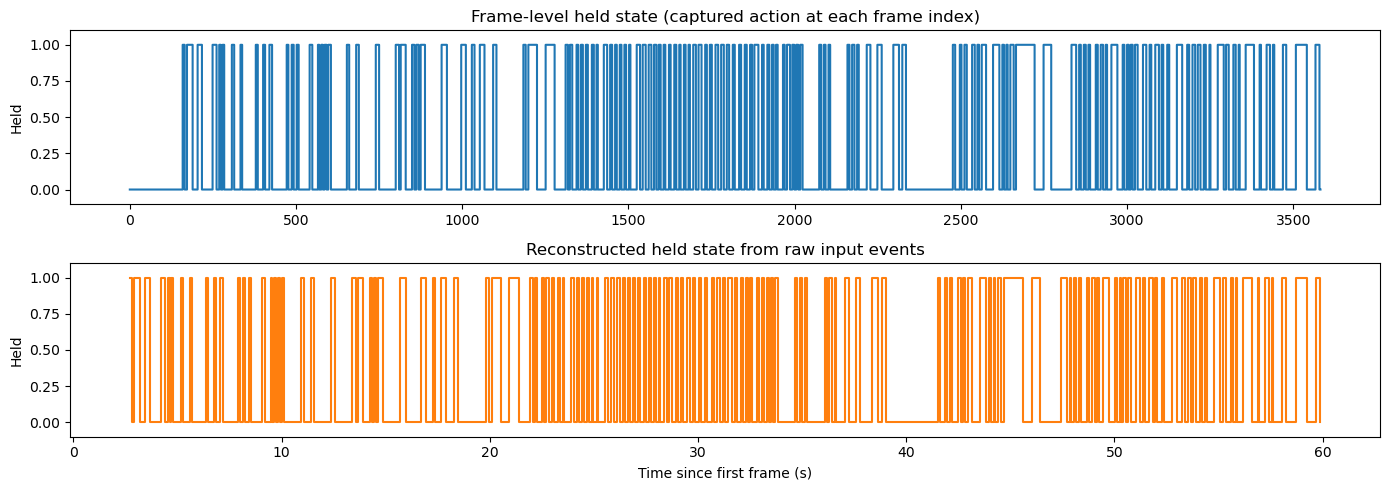

In [4]:
# Reconstruct the held-state timeline from press/release events
events = [
    RawInputEvent(
        run_id=evt["run_id"],
        attempt_id=evt["attempt_id"],
        timestamp=evt["timestamp"],
        device=evt["device"],
        key_code=evt["key_code"],
        kind=InputEventKind(evt["kind"]),
        action=ActionState(evt["action"]),
    )
    for evt in input_events
]
timeline = reconstruct_held_state(events)

# Frame-level held state from the manifest
frame_indices = [fr["frame_index"] for fr in frame_records]
frame_actions = [fr["action"] for fr in frame_records]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=False)

axes[0].step(frame_indices, frame_actions, where="post", color="tab:blue")
axes[0].set_ylabel("Held")
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_title("Frame-level held state (captured action at each frame index)")

if timeline:
    t0 = frame_records[0]["timestamp"]
    event_times, event_states = zip(*timeline)
    rel_times = [t - t0 for t in event_times]
    axes[1].step(rel_times, event_states, where="post", color="tab:orange")
    axes[1].set_xlabel("Time since first frame (s)")
    axes[1].set_ylabel("Held")
    axes[1].set_ylim(-0.1, 1.1)
    axes[1].set_title("Reconstructed held state from raw input events")

plt.tight_layout()
plt.show()

### 9.2 Stage 1 dataset view

The preprocessing pipeline materializes each raw run into aligned observations and rolling frame stacks. Below we load the matching Stage 1 dataset and inspect a sample.

In [5]:
# Locate the matching Stage 1 dataset
dataset_candidates = sorted([
    d for d in DATASETS_DIR.iterdir()
    if d.is_dir() and first_raw_run.name in d.name
])
print("Candidate datasets:", [d.name for d in dataset_candidates])

# Prefer the k8/320x180 variant if present, otherwise the default variant
stage1_dir = next(
    (d for d in dataset_candidates if "k8-320x180" in d.name),
    dataset_candidates[0],
)
print("Selected Stage 1 dataset:", stage1_dir.name)

with (stage1_dir / "dataset_summary.json").open() as f:
    dataset_summary = json.load(f)

with (stage1_dir / "stage1_manifest.jsonl").open() as f:
    manifest_rows = [json.loads(line) for line in f]

print("Dataset summary keys:", list(dataset_summary.keys()))
print(
    f"Samples: {dataset_summary['sample_count']}, "
    f"Held: {dataset_summary['held_count']}, "
    f"Released: {dataset_summary['released_count']}"
)
print(
    f"Observation: {dataset_summary['observation_width']}x"
    f"{dataset_summary['observation_height']}, "
    f"dtype={dataset_summary['observation_dtype']}"
)
print(
    f"Frame stack length: {dataset_summary['frame_stack_length']}, "
    f"layout: {dataset_summary['frame_stack_layout']}"
)

Candidate datasets: ['phase-a-baseline-20260527-0001-stage1', 'phase-a-baseline-20260527-0001-stage1-k8-320x180']
Selected Stage 1 dataset: phase-a-baseline-20260527-0001-stage1-k8-320x180
Dataset summary keys: ['class_weights', 'death_tail_s', 'delta_sys', 'discarded_terminal_window_count', 'frame_stack_layout', 'frame_stack_length', 'frame_stack_schema_version', 'held_count', 'manifest_path', 'observation_dtype', 'observation_height', 'observation_layout', 'observation_schema_version', 'observation_width', 'output_dir', 'released_count', 'reset_skip_s', 'sample_count', 'schema_version', 'source_capture_dir', 'split', 'terminal_event_count']
Samples: 3481, Held: 1169, Released: 2312
Observation: 320x180, dtype=uint8
Frame stack length: 8, layout: khw


Selected sample index 1740 of 3481
Observation shape: (180, 320)
Frame stack shape: (8, 180, 320) action_held: 0


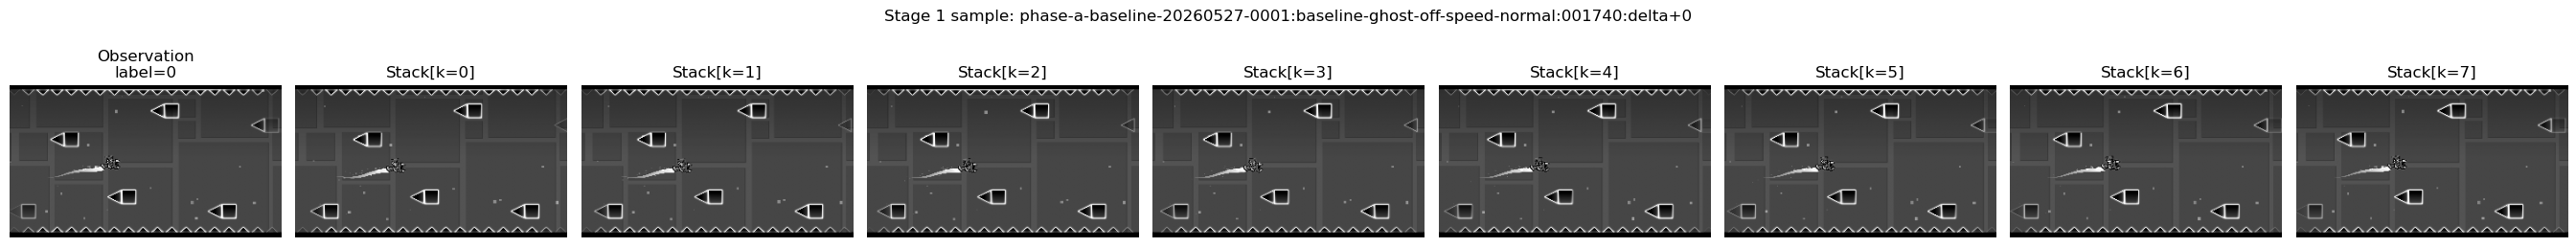

In [6]:
# Load a materialized observation and frame stack from the middle of the run.
# The first frames are the game's pause menu, so we skip ahead.
mid_index = len(manifest_rows) // 2
mid_row = manifest_rows[mid_index]
print(f"Selected sample index {mid_index} of {len(manifest_rows)}")

obs_path = Path(mid_row["observation_path"])
stack_path = Path(mid_row["frame_stack_path"])

# Fallback to dataset-relative paths if the manifest used relative paths
if not obs_path.exists():
    obs_path = stage1_dir / "observations" / obs_path.name
if not stack_path.exists():
    stack_path = stage1_dir / "stacks" / stack_path.name

obs_bytes = obs_path.read_bytes()
stack_bytes = stack_path.read_bytes()

W, H = dataset_summary["observation_width"], dataset_summary["observation_height"]
K = dataset_summary["frame_stack_length"]

observation = np.frombuffer(obs_bytes, dtype=np.uint8).reshape((H, W))
frame_stack = np.frombuffer(stack_bytes, dtype=np.uint8).reshape((K, H, W))

print("Observation shape:", observation.shape)
print("Frame stack shape:", frame_stack.shape, "action_held:", mid_row["action_held"])

fig, axes = plt.subplots(1, K + 1, figsize=(3 * (K + 1), 3))
axes[0].imshow(observation, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Observation\nlabel={mid_row['action_held']}")
axes[0].axis("off")

for k in range(K):
    axes[k + 1].imshow(frame_stack[k], cmap="gray", vmin=0, vmax=255)
    axes[k + 1].set_title(f"Stack[k={k}]")
    axes[k + 1].axis("off")

plt.suptitle(f"Stage 1 sample: {mid_row['sample_id']}")
plt.tight_layout()
plt.show()


Aggregated across 60 Stage 1 datasets:
Total samples: 194550
Held: 53860, Released: 140690
Held ratio: 0.277


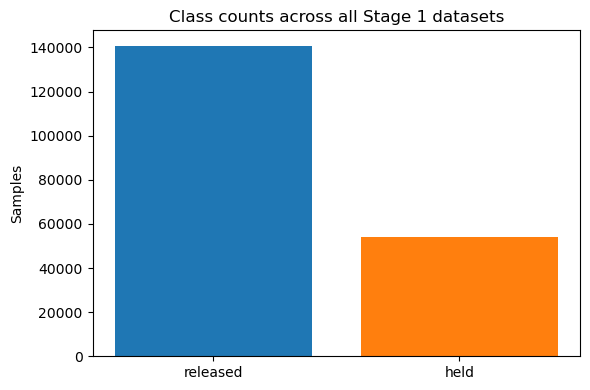

In [7]:
# Aggregate class counts across every materialized Stage 1 dataset
all_summaries = []
for dataset_dir in sorted(DATASETS_DIR.iterdir()):
    summary_path = dataset_dir / "dataset_summary.json"
    if summary_path.exists():
        with summary_path.open() as f:
            all_summaries.append(json.load(f))

total_held = sum(summary["held_count"] for summary in all_summaries)
total_released = sum(summary["released_count"] for summary in all_summaries)
total_samples = sum(summary["sample_count"] for summary in all_summaries)

print(f"Aggregated across {len(all_summaries)} Stage 1 datasets:")
print(f"Total samples: {total_samples}")
print(f"Held: {total_held}, Released: {total_released}")
if total_samples:
    print(f"Held ratio: {total_held / total_samples:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["released", "held"], [total_released, total_held], color=["tab:blue", "tab:orange"])
ax.set_title("Class counts across all Stage 1 datasets")
ax.set_ylabel("Samples")
plt.tight_layout()
plt.show()


### 9.3 Policy showcase: Stereo Madness (unseen level)

This clip shows the exported Voxter policy playing *Stereo Madness*, a standard level that was not part of the training data.


In [8]:
# Display the policy showcase video
showcase_path = PROJECT_ROOT / "assets" / "showcase.mp4"
print("Showcase path:", showcase_path.relative_to(PROJECT_ROOT))

display(Video(str(showcase_path), embed=False, width=640, height=360))


Showcase path: assets/showcase.mp4


## 10. Conclusion

This notebook formalizes the Voxter implementation‑synchronized theory: a recurrent visuomotor policy trained via behavioral cloning and prepared for reinforcement fine‑tuning. We have defined the observation spaces, causal alignment rule, and architecture, detailed the training objectives, and identified the current strengths and limitations. The deployed policy is a promising step toward real‑time Geometry Dash gameplay, but further work is required to certify live performance and to close the gap between microbenchmarks and end‑to‑end control.
